# Section 5.1: Overview of Findings

This notebook provides aggregate statistics and overview analysis across all four empirical tests.

**Purpose:** Report quantitative results aggregated across multiple AI models, present summary statistics, and establish patterns for detailed analysis in subsequent sections.

In [94]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from typing import Dict, List
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from setups.thresholds import (
    T3_DERIVATIVE_SIMILARITY_THRESHOLD,
    T3_STRICT_TRACEABILITY_THRESHOLD,
    T3_SEMANTIC_NOVELTY_DENOM,
    T3_LITERATURE_NOVELTY_THRESHOLD,
    T3_TYPE_FACTOR_FUNCTIONALIST,
    T3_CHALLENGE_FACTOR_FALSE,
    T3_K_NEIGHBORS,
    T3_MANIFOLD_KNN_Q,
    T3_HEATMAP_TOP_N,
    T3_HEATMAP_BOTTOM_N,
    OVERVIEW_CONFIDENCE_LEVEL,
    OVERVIEW_SIGNIFICANCE_ALPHA,
    OVERVIEW_NOVELTY_BINARY_THRESHOLD,
    OVERVIEW_TEST4_ALTERNATIVE_NOVELTY_THRESHOLD,
    OVERVIEW_SIMILARITY_ALERT_THRESHOLD,
    OVERVIEW_T3_TRACEABILITY_SIMILARITY_THRESHOLD,
)

# Use centralized plotting style for this notebook.
plt.style.use('setups/plotstyles.mplstyle')

# Create output directory
Path('results').mkdir(exist_ok=True)
Path('results/figures').mkdir(exist_ok=True)


Bad key colorbar.labelsize in file setups/plotstyles.mplstyle, line 39 ('colorbar.labelsize: 8')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.2/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [95]:
# Create output directory
output_dir = Path('results/test3')
output_dir.mkdir(parents=True, exist_ok=True)

print("Test 3: Theory Generation - Initialization Complete")

output_dir = Path('results/test3_theory_generation')
output_dir.mkdir(parents=True, exist_ok=True)

# -- Similarity / novelty thresholds (loaded from setups.thresholds) ------------
DERIVATIVE_SIMILARITY_THRESHOLD = T3_DERIVATIVE_SIMILARITY_THRESHOLD
STRICT_TRACEABILITY_THRESHOLD = T3_STRICT_TRACEABILITY_THRESHOLD
SEMANTIC_NOVELTY_DENOM = T3_SEMANTIC_NOVELTY_DENOM
LITERATURE_NOVELTY_THRESHOLD = T3_LITERATURE_NOVELTY_THRESHOLD
TYPE_FACTOR_FUNCTIONALIST = T3_TYPE_FACTOR_FUNCTIONALIST
CHALLENGE_FACTOR_FALSE = T3_CHALLENGE_FACTOR_FALSE

# Canonical artifact consumed by section_5-4_test3.ipynb.
TRACEABILITY_CANONICAL_FILE = output_dir / 'test3_traceability_canonical.csv'

# Alternative (calibrated) novelty analysis parameters
K_NEIGHBORS = T3_K_NEIGHBORS
MANIFOLD_KNN_Q = T3_MANIFOLD_KNN_Q
DERIVATIVE_SIMILARITY_THRESHOLD_LEGACY = DERIVATIVE_SIMILARITY_THRESHOLD  # alias

# -- Heatmap display parameters ------------------------------------------------
HEATMAP_TOP_N = T3_HEATMAP_TOP_N
HEATMAP_BOTTOM_N = T3_HEATMAP_BOTTOM_N
HEATMAP_GAP_LINE = HEATMAP_TOP_N + 0.5

# -- Global colormaps / palettes ----------------------------------------------
WHITE_SKY_CMAP = LinearSegmentedColormap.from_list("white_sky", ["#ffffff", "#0057e7"])
SKY_WHITE_GRAY_CMAP = LinearSegmentedColormap.from_list("skywhitegray", ["#1e90ff", "#ffffff", "#808080"] )

BLUE_GRAY_RAMP = [
    "#0b3c8c",
    "#2f6fc2",
    "#79aeea",
    "#9a9a9a",
    "#c7c7c7",
    "#efefef",
]
SIMILARITY_HIST_COLOR = "#79aeea"
THRESHOLD_COLOR = "#5f5f5f"
TEXT_COLOR = "#000000"

MODEL_VISIBLE_COLORS = [
    "#0b3c8c",
    "#1f5fb3",
    "#2f6fc2",
    "#4f86cf",
    "#6d9edc",
    "#6f6f6f",
    "#8a8a8a",
    "#a8a8a8",
    "#c7c7c7",
]

Test 3: Theory Generation - Initialization Complete


In [96]:
# Centralized analysis thresholds loaded from setups.thresholds.
ANALYSIS_CONFIG = {
    'confidence_level': OVERVIEW_CONFIDENCE_LEVEL,
    'significance_alpha': OVERVIEW_SIGNIFICANCE_ALPHA,
    'novelty_binary_threshold': OVERVIEW_NOVELTY_BINARY_THRESHOLD,
    'test4_alternative_novelty_threshold': OVERVIEW_TEST4_ALTERNATIVE_NOVELTY_THRESHOLD,
    'similarity_alert_threshold': OVERVIEW_SIMILARITY_ALERT_THRESHOLD,
    'test3_traceability_similarity_threshold': OVERVIEW_T3_TRACEABILITY_SIMILARITY_THRESHOLD,
}

print('Analysis config loaded from setups.thresholds:', ANALYSIS_CONFIG)

Analysis config loaded from setups.thresholds: {'confidence_level': 0.95, 'significance_alpha': 0.05, 'novelty_binary_threshold': 0.5, 'test4_alternative_novelty_threshold': 4.0, 'similarity_alert_threshold': 0.8, 'test3_traceability_similarity_threshold': 0.55}


## 1. Load Results from All Tests

In [97]:
def _normalize_model_names(df: pd.DataFrame) -> pd.DataFrame:
    """Canonicalize known model aliases to avoid split rows across tests."""
    df = df.copy()

    model_col = next((c for c in df.columns if c.lower() == 'model'), None)
    if model_col is None:
        return df

    aliases = {
        'perplexity-sonar': 'perplexity-sonar-pro',
        'perplexity/sonar': 'perplexity-sonar-pro',
        'perplexity/sonar-pro': 'perplexity-sonar-pro',
        'perplexity-sonar-pro-pro': 'perplexity-sonar-pro',
    }

    df[model_col] = (
        df[model_col]
        .astype(str)
        .str.strip()
        .replace(aliases)
    )
    return df


def load_test_results(test_name: str) -> pd.DataFrame:
    """Load a canonical main-test result CSV into a DataFrame."""
    file_map = {
        "test1_ontological_innovation": "results/test1_ontological_innovation/test1_results.csv",
        "test2_epistemic_agency": "results/test2_epistemic_agency/test2_results.csv",
        "test3_theory_generation": "results/test3_theory_generation/test3_results.csv",
        "test4_category_recognition": "results/test4_category_recognition/test4_results.csv",
    }

    if test_name not in file_map:
        raise ValueError(f"Unknown test name: {test_name}")

    results_path = Path(file_map[test_name])
    if not results_path.exists():
        raise FileNotFoundError(f"Results file not found: {results_path}")

    df = pd.read_csv(results_path)
    df = _normalize_model_names(df)
    print(f"Loaded {test_name} from: {results_path}")
    return df

In [98]:
test1_results = load_test_results("test1_ontological_innovation")
test2_results = load_test_results("test2_epistemic_agency")
test3_results = load_test_results("test3_theory_generation")
test4_results = load_test_results("test4_category_recognition")

print("Test results loaded.")
print(f"Test 1: {len(test1_results)} samples")
print(f"Test 2: {len(test2_results)} samples")
print(f"Test 3: {len(test3_results)} samples")
print(f"Test 4: {len(test4_results)} samples")

Loaded test1_ontological_innovation from: results/test1_ontological_innovation/test1_results.csv
Loaded test2_epistemic_agency from: results/test2_epistemic_agency/test2_results.csv
Loaded test3_theory_generation from: results/test3_theory_generation/test3_results.csv
Loaded test4_category_recognition from: results/test4_category_recognition/test4_results.csv
Test results loaded.
Test 1: 168 samples
Test 2: 840 samples
Test 3: 168 samples
Test 4: 168 samples


In [99]:
test1_results.head()

,proposal_id,proposal_name,model,is_extension,is_hybrid,is_functional_recomb,is_traceable,related_modalities,inside_convex_hull,closest_modality,...,lit_matches,lit_best_score,lit_best_text,lit_best_title,lit_best_source_type,lit_best_evidence_tier,novelty_semantic_proxy,novelty_frontier_distance_proxy,continuous_novelty_score,is_novel
0,sample_000,Chronesthesia,deepseek-v3.2,False,False,False,True,NaN,True,PROPRIOCEPTIVE,...,10,0.564024,This paper introduces the concept of Human Sta...,Temporal Experience and Human State Field: Tow...,internet_scholarly_api,strong,0.551226,2.0,0.074600,NO
1,sample_001,Temporal Resonance Perception (TRP),mistral-large,True,False,False,True,visual,True,VISUAL,...,4,0.451118,This paper introduces the concept of Human Sta...,Temporal Experience and Human State Field: Tow...,internet_scholarly_api,strong,0.702463,3.0,0.034974,NO
2,sample_002,Chronoperception,deepseek-v3.2,False,False,False,True,NaN,True,PROPRIOCEPTIVE,...,10,0.536659,This paper introduces the concept of Human Sta...,Temporal Experience and Human State Field: Tow...,internet_scholarly_api,strong,0.651085,2.0,0.088115,NO
3,sample_003,Chronoceptive Modality,llama-3.3-70b-instruct,False,False,False,True,NaN,True,INTEROCEPTIVE,...,10,0.590939,This paper introduces the concept of Human Sta...,Temporal Experience and Human State Field: Tow...,internet_scholarly_api,strong,0.604596,2.0,0.081823,NO
4,sample_004,Temporoceptive,deepseek-v3.2,False,False,True,True,vestibular,True,VESTIBULAR,...,5,0.528159,This paper introduces the concept of Human Sta...,Temporal Experience and Human State Field: Tow...,internet_scholarly_api,strong,0.693170,3.0,0.034511,NO


## 2. Aggregate Statistics Across All Tests

**Threshold policy used in this section**

- A shared novelty threshold is applied where a continuous novelty score exists: `ANALYSIS_CONFIG['novelty_binary_threshold']`.
- For tests that provide only binary novelty fields (or test-specific operationalizations), the native field is used.
- Traceability uses strict per-test labels when available (for example `is_traceable` exported by the test pipeline).

**Methodological note**

A single global threshold is not always possible across all tests because each test operationalizes novelty and traceability differently. This notebook therefore applies global thresholds only where constructs are directly comparable and otherwise preserves each test's native validated definition.

In [100]:

def stats_bootstrap_ci(data: np.ndarray, n_bootstrap: int = 10000, ci: float = 0.95) -> tuple:
    """Compute bootstrap confidence interval for numeric arrays."""
    arr = np.asarray(data, dtype=float)
    arr = arr[~np.isnan(arr)]
    if arr.size == 0:
        return (np.nan, np.nan)

    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(arr, size=len(arr), replace=True)
        bootstrap_means.append(np.mean(sample))

    alpha = 1 - ci
    lower = np.percentile(bootstrap_means, alpha / 2 * 100)
    upper = np.percentile(bootstrap_means, (1 - alpha / 2) * 100)
    return (float(lower), float(upper))


def _to_binary_numeric(series: pd.Series) -> pd.Series:
    """Convert boolean/text flags to numeric 0/1, or pass through numeric values as-is."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)

    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce').astype(float)

    mapping = {
        'true': 1.0, 't': 1.0, 'yes': 1.0, 'y': 1.0, '1': 1.0,
        'false': 0.0, 'f': 0.0, 'no': 0.0, 'n': 0.0, '0': 0.0,
        'no': 0.0, 'maybe': 1.0,
    }
    as_str = series.astype(str).str.strip().str.lower()
    return as_str.map(mapping).astype(float)


def _apply_novelty_threshold(score_series: pd.Series, threshold: float) -> pd.Series:
    """Convert continuous novelty scores to binary novelty using a shared threshold."""
    vals = pd.to_numeric(score_series, errors='coerce')
    return vals.ge(threshold).astype(float)


def compute_aggregate_stats(df: pd.DataFrame, test_name: str) -> Dict:
    """Compute aggregate statistics aligned to the current CSV schemas."""
    df = df.copy()
    df.columns = df.columns.map(str.lower)

    ci_level = ANALYSIS_CONFIG.get('confidence_level', 0.95) if 'ANALYSIS_CONFIG' in globals() else 0.95
    novelty_thr = ANALYSIS_CONFIG.get('novelty_binary_threshold', 0.5) if 'ANALYSIS_CONFIG' in globals() else 0.5

    stats = {
        'test_name': test_name,
        'total_samples': len(df),
        'n_models': int(df['model'].nunique()) if 'model' in df.columns else 0,
        'models': df['model'].dropna().unique().tolist() if 'model' in df.columns else [],
    }

    # Novelty signal by test schema — priority order mirrors per-test section notebooks:
    #   T1 → continuous_novelty_score (hybrid frontier score, [0,1])
    #   T3 → continuous_literature_novelty (literature-grounded score, [0,1])
    #   T4 → total_score / 15         (total category-recognition score, 0-15 → 0-1)
    #   T2 → transcends_framework     (binary transcendence flag)
    if 'continuous_novelty_score' in df.columns:
        cont = pd.to_numeric(df['continuous_novelty_score'], errors='coerce').clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Continuous novelty score (mean)'
    elif 'continuous_literature_novelty' in df.columns:
        cont = pd.to_numeric(df['continuous_literature_novelty'], errors='coerce').clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Continuous literature novelty (mean)'
    elif 'global_novelty_score' in df.columns:
        cont = pd.to_numeric(df['global_novelty_score'], errors='coerce').clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Global novelty score (mean)'
    elif 'novelty_score' in df.columns:
        cont = pd.to_numeric(df['novelty_score'], errors='coerce').clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Novelty score (mean)'
    elif 'novelty_ratio' in df.columns:
        cont = pd.to_numeric(df['novelty_ratio'], errors='coerce').clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Novelty ratio (mean)'
    elif 'total_score' in df.columns:
        # T4: total category-recognition score (0-15), normalized to [0,1] for overview comparisons.
        cont = (pd.to_numeric(df['total_score'], errors='coerce') / 15.0).clip(0, 1)
        novel_vals = _apply_novelty_threshold(cont, novelty_thr)
        stats['novel_threshold'] = novelty_thr
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = float(cont.mean())
        stats['prop_novel_kind_ci'] = stats_bootstrap_ci(cont.to_numpy(), ci=ci_level)
        stats['novel_kind_label'] = 'Total score / 15 (normalized mean)'
    elif 'is_novel' in df.columns:
        novel_vals = _to_binary_numeric(df['is_novel'])
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = stats['prop_novel']
        stats['prop_novel_kind_ci'] = stats['prop_novel_ci']
        stats['novel_kind_label'] = 'Ontological novelty (binary field)'
    elif 'ontologically_novel' in df.columns:
        novel_vals = _to_binary_numeric(df['ontologically_novel'])
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = stats['prop_novel']
        stats['prop_novel_kind_ci'] = stats['prop_novel_ci']
        stats['novel_kind_label'] = 'Ontological novelty (legacy binary field)'
    elif 'transcends_framework' in df.columns:
        # T2: framework transcendence (matches section 5-3 primary metric).
        novel_vals = _to_binary_numeric(df['transcends_framework'])
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = stats['prop_novel']
        stats['prop_novel_kind_ci'] = stats['prop_novel_ci']
        stats['novel_kind_label'] = 'Framework transcendence (binary)'
    elif 'novel_non_functionalist' in df.columns:
        novel_vals = _to_binary_numeric(df['novel_non_functionalist'])
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = stats['prop_novel']
        stats['prop_novel_kind_ci'] = stats['prop_novel_ci']
        stats['novel_kind_label'] = 'Non-functionalist novelty (binary field)'
    elif 'original' in df.columns:
        novel_vals = _to_binary_numeric(df['original'])
        stats['prop_novel'] = float(novel_vals.mean())
        stats['prop_novel_ci'] = stats_bootstrap_ci(novel_vals.to_numpy(), ci=ci_level)
        stats['prop_novel_kind'] = stats['prop_novel']
        stats['prop_novel_kind_ci'] = stats['prop_novel_ci']
        stats['novel_kind_label'] = 'Originality (binary field)'

    # Traceability / derivativeness by test schema.
    if 'is_traceable' in df.columns:
        trace_vals = _to_binary_numeric(df['is_traceable'])
        stats['prop_traceable'] = float(trace_vals.mean())
        stats['prop_traceable_ci'] = stats_bootstrap_ci(trace_vals.to_numpy(), ci=ci_level)
    elif 'lit_matches' in df.columns:
        trace_vals = pd.to_numeric(df['lit_matches'], errors='coerce').fillna(0).gt(0).astype(float)
        stats['prop_traceable'] = float(trace_vals.mean())
        stats['prop_traceable_ci'] = stats_bootstrap_ci(trace_vals.to_numpy(), ci=ci_level)
    elif 'training_derived' in df.columns:
        trace_vals = _to_binary_numeric(df['training_derived'])
        stats['prop_traceable'] = float(trace_vals.mean())
        stats['prop_traceable_ci'] = stats_bootstrap_ci(trace_vals.to_numpy(), ci=ci_level)
    elif 'likely_derivative' in df.columns:
        trace_vals = _to_binary_numeric(df['likely_derivative'])
        stats['prop_traceable'] = float(trace_vals.mean())
        stats['prop_traceable_ci'] = stats_bootstrap_ci(trace_vals.to_numpy(), ci=ci_level)

    # Similarity metric names used in current CSVs.
    if 'max_similarity' in df.columns:
        sim_vals = pd.to_numeric(df['max_similarity'], errors='coerce')
        stats['mean_similarity'] = float(sim_vals.mean())
        stats['std_similarity'] = float(sim_vals.std())
    elif 'similarity' in df.columns:
        sim_vals = pd.to_numeric(df['similarity'], errors='coerce')
        stats['mean_similarity'] = float(sim_vals.mean())
        stats['std_similarity'] = float(sim_vals.std())

    return stats


def print_aggregate_summary(all_stats: List[Dict], include_extended: bool = False) -> pd.DataFrame:
    """Print aggregate summaries and return the summary DataFrame."""
    summary_df = pd.DataFrame(all_stats)

    print("\n=== AGGREGATE STATISTICS ACROSS ALL TESTS ===")
    print(summary_df[['test_name', 'total_samples', 'n_models']].to_string(index=False))

    if include_extended:
        cols = ['test_name', 'total_samples', 'n_models']
        for extra in ['prop_novel', 'prop_novel_kind', 'prop_traceable', 'mean_similarity']:
            if extra in summary_df.columns:
                cols.append(extra)
        print("\n=== EXTENDED SUMMARY (WHERE AVAILABLE) ===")
        print(summary_df[cols].to_string(index=False))

    print("\n=== NOVELTY AND TRACEABILITY ===")
    for stat in all_stats:
        print(f"{stat['test_name']}:")
        if 'prop_novel' in stat:
            thr_suffix = f" (threshold >= {stat['novel_threshold']:g})" if 'novel_threshold' in stat else ""
            print(
                f"  Novel outputs{thr_suffix}: {stat['prop_novel']:.1%} "
                f"[{stat['prop_novel_ci'][0]:.1%}, {stat['prop_novel_ci'][1]:.1%}]"
            )
        if 'prop_novel_kind' in stat and 'novel_kind_label' in stat:
            print(
                f"  Novelty-kind ({stat['novel_kind_label']}): {stat['prop_novel_kind']:.1%} "
                f"[{stat['prop_novel_kind_ci'][0]:.1%}, {stat['prop_novel_kind_ci'][1]:.1%}]"
            )
        if 'prop_traceable' in stat:
            print(
                f"  Traceable: {stat['prop_traceable']:.1%} "
                f"[{stat['prop_traceable_ci'][0]:.1%}, {stat['prop_traceable_ci'][1]:.1%}]"
            )

    return summary_df


# Compute statistics once (canonical source for downstream cells)
all_stats = [
    compute_aggregate_stats(test1_results, 'Test 1: Ontological Innovation'),
    compute_aggregate_stats(test2_results, 'Test 2: Epistemic Agency'),
    compute_aggregate_stats(test3_results, 'Test 3: Theory Generation'),
    compute_aggregate_stats(test4_results, 'Test 4: Category Recognition'),
]

summary_df = print_aggregate_summary(all_stats, include_extended=False)



=== AGGREGATE STATISTICS ACROSS ALL TESTS ===
                     test_name  total_samples  n_models
Test 1: Ontological Innovation            168         7
      Test 2: Epistemic Agency            840         7
     Test 3: Theory Generation            168         7
  Test 4: Category Recognition            168         7

=== NOVELTY AND TRACEABILITY ===
Test 1: Ontological Innovation:
  Novel outputs (threshold >= 0.5): 0.0% [0.0%, 0.0%]
  Novelty-kind (Continuous novelty score (mean)): 5.9% [5.3%, 6.5%]
  Traceable: 98.2% [95.8%, 100.0%]
Test 2: Epistemic Agency:
  Novel outputs: 4.8% [3.3%, 6.3%]
  Novelty-kind (Framework transcendence (binary)): 4.8% [3.3%, 6.3%]
  Traceable: 100.0% [100.0%, 100.0%]
Test 3: Theory Generation:
  Novel outputs (threshold >= 0.5): 27.4% [20.8%, 33.9%]
  Novelty-kind (Continuous literature novelty (mean)): 32.0% [29.3%, 34.8%]
  Traceable: 100.0% [100.0%, 100.0%]
Test 4: Category Recognition:
  Novel outputs (threshold >= 0.5): 63.7% [56.5%, 70.8%]

In [101]:
# Keep a single canonical compute_aggregate_stats implementation (defined in Cell 10).
print("Using aggregate-statistics function defined in Cell 10 (schema-aligned with current CSVs).")

# Quick consistency check: required columns by test
required_by_test = {
    "Test 1": ["model", "is_novel", "is_traceable", "max_similarity"],
    "Test 2": ["model", "original", "training_derived", "max_similarity"],
    # Latest Test 3 pipeline schema (fallbacks accepted below)
    "Test 3": ["model", "novelty_score", "is_traceable", "max_similarity"],
    "Test 4": ["model", "training_derived", "similarity"],
}

legacy_alternatives = {
    "Test 1": {
        "is_novel": ["ontologically_novel", "continuous_novelty_score"],
        "is_traceable": ["lit_matches"],
    },
    "Test 2": {
        "original": ["novelty_score", "novelty_ratio", "transcends_framework", "is_transcendent"],
    },
    "Test 3": {
        "novelty_score": ["continuous_literature_novelty", "literature_novelty_score", "novel_non_functionalist"],
        "is_traceable": ["likely_derivative"],
        "max_similarity": ["similarity"],
    },
}

available = {
    "Test 1": set(test1_results.columns.str.lower()),
    "Test 2": set(test2_results.columns.str.lower()),
    "Test 3": set(test3_results.columns.str.lower()),
    "Test 4": set(test4_results.columns.str.lower()),
}

for test_name, required_cols in required_by_test.items():
    missing = [c for c in required_cols if c not in available[test_name]]
    if test_name in legacy_alternatives and missing:
        reduced_missing = []
        for c in missing:
            alts = legacy_alternatives[test_name].get(c, [])
            if any(a in available[test_name] for a in alts):
                continue
            reduced_missing.append(c)
        missing = reduced_missing

    if missing:
        print(f"{test_name}: missing columns -> {missing}")
    else:
        print(f"{test_name}: schema OK")


Using aggregate-statistics function defined in Cell 10 (schema-aligned with current CSVs).
Test 1: schema OK
Test 2: schema OK
Test 3: missing columns -> ['max_similarity']
Test 4: schema OK


In [102]:
# Reuse canonical aggregate results from Cell 8 and show only the extended table.
if 'summary_df' not in globals():
    raise RuntimeError('Run Cell 8 first to compute aggregate statistics.')

cols = ['test_name', 'total_samples', 'n_models']
for extra in ['prop_novel', 'prop_traceable', 'mean_similarity']:
    if extra in summary_df.columns:
        cols.append(extra)

print("\n=== EXTENDED SUMMARY (WHERE AVAILABLE) ===")
print(summary_df[cols].to_string(index=False))


=== EXTENDED SUMMARY (WHERE AVAILABLE) ===
                     test_name  total_samples  n_models  prop_novel  prop_traceable  mean_similarity
Test 1: Ontological Innovation            168         7    0.000000        0.982143         0.305261
      Test 2: Epistemic Agency            840         7    0.047619        1.000000         0.580906
     Test 3: Theory Generation            168         7    0.273810        1.000000              NaN
  Test 4: Category Recognition            168         7    0.636905        0.952381         0.461506


## 3. Cross-Model Comparison

In [103]:

# Section 3: Cross-model comparison with schema-aware novelty metrics

test2_compare_df = test2_results
print("Using canonical Test 2 file for model comparison: results/test2_epistemic_agency/test2_results.csv")


def compare_models(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    model_stats = df.groupby('model')[metric].agg(['mean', 'std', 'count'])
    cis = []
    for model in model_stats.index:
        model_data = pd.to_numeric(df.loc[df['model'] == model, metric], errors='coerce').dropna().values
        ci = stats_bootstrap_ci(model_data) if len(model_data) > 0 else (np.nan, np.nan)
        cis.append(ci)
    model_stats['ci_lower'] = [ci[0] for ci in cis]
    model_stats['ci_upper'] = [ci[1] for ci in cis]
    return model_stats


def pick_metric_column(df: pd.DataFrame, candidates: List[str]) -> str | None:
    lower_to_original = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_to_original:
            return lower_to_original[c.lower()]
    return None


def _to_binary_numeric_local(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce').astype(float)
    mapping = {
        'true': 1.0, 't': 1.0, 'yes': 1.0, 'y': 1.0, '1': 1.0,
        'false': 0.0, 'f': 0.0, 'no': 0.0, 'n': 0.0, '0': 0.0,
    }
    return series.astype(str).str.strip().str.lower().map(mapping).astype(float)


def select_test_specific_metric(df: pd.DataFrame, test_name: str) -> tuple[pd.Series | None, str]:
    # Test 1: hybrid continuous frontier-distance score (matches section 5-2).
    if test_name == 'Test 1: Ontological Innovation':
        col = pick_metric_column(df, ['continuous_novelty_score'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f"{col} (hybrid continuous score)"

    # Test 2: framework transcendence binary flag (matches section 5-3 primary axis).
    if test_name == 'Test 2: Epistemic Agency':
        col = pick_metric_column(df, ['novelty_score', 'novelty_ratio'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f"{col} (direct score)"
        col = pick_metric_column(df, ['transcends_framework', 'is_transcendent'])
        if col is not None:
            return _to_binary_numeric_local(df[col]), f"{col} (binary novelty)"

    # Test 3: use literature-grounded continuous novelty for cross-model divergence.
    if test_name == 'Test 3: Theory Generation':
        col = pick_metric_column(df, ['continuous_literature_novelty', 'literature_novelty_score', 'global_novelty_score'])
        if col is not None:
            return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f"{col} (literature-grounded continuous score)"

    # Test 4: total category-recognition score normalized to [0,1] (matches section 5-5 primary metric).
    if test_name == 'Test 4: Category Recognition':
        col = pick_metric_column(df, ['total_score'])
        if col is not None:
            vals = pd.to_numeric(df[col], errors='coerce')
            return (vals / 15.0).clip(0, 1), f"{col} / 15 (normalized to [0,1])"

    # Generic fallbacks
    col = pick_metric_column(df, ['is_novel', 'ontologically_novel', 'novel_non_functionalist', 'original'])
    if col is not None:
        return _to_binary_numeric_local(df[col]), f"{col} (binary novelty)"

    col = pick_metric_column(df, ['novelty_score', 'novelty_ratio'])
    if col is not None:
        return pd.to_numeric(df[col], errors='coerce').clip(0, 1), f"{col} (direct score)"

    col = pick_metric_column(df, ['alternative_score'])
    if col is not None:
        vals = pd.to_numeric(df[col], errors='coerce')
        return ((vals - 1.0) / 4.0).clip(0, 1), f"{col} normalized to [0,1]"

    col = pick_metric_column(df, ['max_similarity', 'similarity'])
    if col is not None:
        sim = pd.to_numeric(df[col], errors='coerce')
        return (1.0 - sim).clip(0, 1), f"1 - {col} (novelty proxy)"

    return None, 'no supported metric'


def extract_traceability_series(df: pd.DataFrame, test_name: str, similarity_threshold: float = 0.8) -> tuple[pd.Series | None, str]:
    # Test 3: use canonical main-test columns.
    if test_name == 'Test 3: Theory Generation':
        sim_col = pick_metric_column(df, ['similarity_max_to_known', 'max_similarity', 'similarity'])
        der_col = pick_metric_column(df, ['likely_derivative'])
        if sim_col is not None:
            t3_thr = ANALYSIS_CONFIG.get('test3_traceability_similarity_threshold', 0.55)
            sim_flag = pd.to_numeric(df[sim_col], errors='coerce').ge(t3_thr)
            if der_col is not None:
                der_flag = _to_binary_numeric_local(df[der_col]).fillna(0).ge(0.5)
                return (sim_flag | der_flag).astype(float), f"({sim_col} >= {t3_thr:g}) OR {der_col}"
            return sim_flag.astype(float), f"{sim_col} >= {t3_thr:g}"

    col = pick_metric_column(df, ['is_traceable'])
    if col is not None:
        return _to_binary_numeric_local(df[col]), col

    col = pick_metric_column(df, ['likely_derivative', 'training_derived'])
    if col is not None:
        return _to_binary_numeric_local(df[col]), col

    col = pick_metric_column(df, ['max_similarity', 'similarity', 'similarity_max_to_known'])
    if col is not None:
        sim = pd.to_numeric(df[col], errors='coerce')
        return (sim >= similarity_threshold).astype(float), f"{col} >= {similarity_threshold:g}"

    return None, 'no supported traceability metric'


print('=' * 80)
print('CROSS-MODEL COMPARISON (SCHEMA-AWARE)')
print('=' * 80)

test_frames = [
    ('T1', 'Test 1: Ontological Innovation', test1_results),
    ('T2', 'Test 2: Epistemic Agency', test2_compare_df),
    ('T3', 'Test 3: Theory Generation', test3_results),
    ('T4', 'Test 4: Category Recognition', test4_results),
]

similarity_alert = ANALYSIS_CONFIG.get('similarity_alert_threshold', 0.8)
all_stats = []
metric_legend_rows = []
all_model_stats = []

for test_code, test_title, df in test_frames:
    metric_series, metric_label = select_test_specific_metric(df, test_title)
    trace_series, trace_label = extract_traceability_series(df, test_title, similarity_threshold=similarity_alert)

    metric_legend_rows.append({'test': test_code, 'metric': metric_label, 'traceability_metric': trace_label})
    if metric_series is None:
        continue

    model_col = pick_metric_column(df, ['model'])
    if model_col is None:
        continue

    tmp = pd.DataFrame({'model': df[model_col], 'metric': metric_series})
    tmp = tmp.dropna(subset=['model', 'metric'])

    if trace_series is not None:
        tmp = tmp.join(pd.DataFrame({'trace': trace_series}))

    prop_novel = float(tmp['metric'].mean()) if not tmp.empty else np.nan
    prop_novel_ci = stats_bootstrap_ci(tmp['metric'].values) if not tmp.empty else (np.nan, np.nan)

    prop_trace = np.nan
    prop_trace_ci = (np.nan, np.nan)
    if 'trace' in tmp.columns:
        trace_vals = pd.to_numeric(tmp['trace'], errors='coerce').dropna().values
        if len(trace_vals) > 0:
            prop_trace = float(np.mean(trace_vals))
            prop_trace_ci = stats_bootstrap_ci(trace_vals)

    model_stats = compare_models(tmp.rename(columns={'metric': 'novelty_metric'}), 'novelty_metric')
    model_stats = model_stats.reset_index().rename(columns={'index': 'model'})
    model_stats['test'] = test_code
    all_model_stats.append(model_stats)

    all_stats.append({
        'test': test_title,
        'test_code': test_code,
        'total_samples': int(len(tmp)),
        'models': sorted(tmp['model'].dropna().unique().tolist()),
        'prop_novel': prop_novel,
        'prop_novel_ci': tuple(float(x) for x in prop_novel_ci),
        'prop_novel_kind': prop_novel,
        'prop_novel_kind_ci': tuple(float(x) for x in prop_novel_ci),
        'prop_traceable': prop_trace,
        'prop_traceable_ci': tuple(float(x) for x in prop_trace_ci),
        'metric_label': metric_label,
        'traceability_label': trace_label,
    })

all_model_stats = pd.concat(all_model_stats, ignore_index=True) if all_model_stats else pd.DataFrame()
cross_test_metric_legend = pd.DataFrame(metric_legend_rows)
metric_df = all_model_stats.copy()

if not all_model_stats.empty:
    cross_test_model_matrix = all_model_stats.pivot_table(index='model', columns='test', values='mean', aggfunc='mean')
    cross_test_model_matrix = cross_test_model_matrix.reindex(columns=['T1', 'T2', 'T3', 'T4'])

    cross_test_model_matrix_z = cross_test_model_matrix.copy()
    for col in cross_test_model_matrix_z.columns:
        s = cross_test_model_matrix_z[col]
        if s.notna().sum() >= 2 and not np.isclose(float(s.std(skipna=True)), 0.0):
            cross_test_model_matrix_z[col] = (s - s.mean(skipna=True)) / s.std(skipna=True)
        else:
            cross_test_model_matrix_z[col] = np.nan
    cross_test_model_matrix_z = cross_test_model_matrix_z.fillna(0.0)

    cross_test_model_summary = (
        all_model_stats.groupby('model', as_index=False)['mean']
        .mean()
        .rename(columns={'mean': 'mean_across_tests'})
        .sort_values('mean_across_tests', ascending=False)
    )
else:
    cross_test_model_matrix = pd.DataFrame()
    cross_test_model_matrix_z = pd.DataFrame()
    cross_test_model_summary = pd.DataFrame(columns=['model', 'mean_across_tests'])

print('\nMetric legend by test:')
display(cross_test_metric_legend)

if not cross_test_model_matrix.empty:
    print('\nModel-by-test matrix (raw means):')
    display(cross_test_model_matrix.round(3))

    print('\nModel-by-test matrix (within-test z-scores):')
    display(cross_test_model_matrix_z.round(3))

if not metric_df.empty:
    print('\nPer-model detailed metrics (separated by test):')
    ordered_tests = ['T1', 'T2', 'T3', 'T4']
    for t in ordered_tests:
        block = metric_df[metric_df['test'] == t].sort_values('model').reset_index(drop=True)
        if block.empty:
            continue
        print('\n' + '-' * 90)
        print(f'{t} detailed metrics')
        print('-' * 90)
        display(block)

if not cross_test_model_summary.empty:
    print('\nModel ranking by mean novelty-oriented score across tests:')
    display(cross_test_model_summary)
else:
    print('\nNo cross-model summary could be computed.')


Using canonical Test 2 file for model comparison: results/test2_epistemic_agency/test2_results.csv
CROSS-MODEL COMPARISON (SCHEMA-AWARE)

Metric legend by test:


,test,metric,traceability_metric
0,T1,continuous_novelty_score (hybrid continuous sc...,is_traceable
1,T2,Transcends_Framework (binary novelty),Training_Derived
2,T3,Continuous_Literature_Novelty (literature-grou...,(Similarity_Max_To_Known >= 0.55) OR Likely_De...
3,T4,"Total_Score / 15 (normalized to [0,1])",Training_Derived



Model-by-test matrix (raw means):


test,T1,T2,T3,T4
model,,,,
claude-3.7-sonnet,0.070,0.083,0.362,0.594
deepseek-v3.2,0.063,0.067,0.380,0.692
gemini-3.1-pro-preview,0.078,0.000,0.366,0.461
gpt-5.2,0.014,0.042,0.526,0.825
llama-3.3-70b-instruct,0.082,0.008,0.158,0.381
mistral-large,0.072,0.050,0.139,0.758
perplexity-sonar-pro,0.035,0.083,0.311,0.428



Model-by-test matrix (within-test z-scores):


...

,model,mean,std,count,ci_lower,ci_upper,test
0,claude-3.7-sonnet,0.361877,0.128905,24,0.311855,0.411980,T3
1,deepseek-v3.2,0.379979,0.128487,24,0.327758,0.429165,T3
2,gemini-3.1-pro-preview,0.366033,0.180355,24,0.295420,0.436132,T3
3,gpt-5.2,0.526332,0.118092,24,0.475204,0.566419,T3
4,llama-3.3-70b-instruct,0.157606,0.147807,24,0.105709,0.221453,T3
5,mistral-large,0.139071,0.056647,24,0.117622,0.162023,T3
6,perplexity-sonar-pro,0.311368,0.152248,24,0.252212,0.372555,T3



------------------------------------------------------------------------------------------
T4 detailed metrics
------------------------------------------------------------------------------------------


,model,mean,std,count,ci_lower,ci_upper,test
0,claude-3.7-sonnet,0.594444,0.083212,24,0.558333,0.625000,T4
1,deepseek-v3.2,0.691667,0.114314,24,0.647222,0.736111,T4
2,gemini-3.1-pro-preview,0.461111,0.103870,24,0.422222,0.502778,T4
3,gpt-5.2,0.825000,0.054948,24,0.805556,0.847222,T4
4,llama-3.3-70b-instruct,0.380556,0.079805,24,0.350000,0.411111,T4
5,mistral-large,0.758333,0.058359,24,0.736111,0.783333,T4
6,perplexity-sonar-pro,0.427778,0.117817,24,0.383333,0.475000,T4



Model ranking by mean novelty-oriented score across tests:


,model,mean_across_tests
3,gpt-5.2,0.351626
1,deepseek-v3.2,0.300412
0,claude-3.7-sonnet,0.277522
5,mistral-large,0.254879
2,gemini-3.1-pro-preview,0.226196
6,perplexity-sonar-pro,0.214300
4,llama-3.3-70b-instruct,0.157009


Cross-test model comparison heatmaps saved to: results/overview/cross-test_model-comparison.png


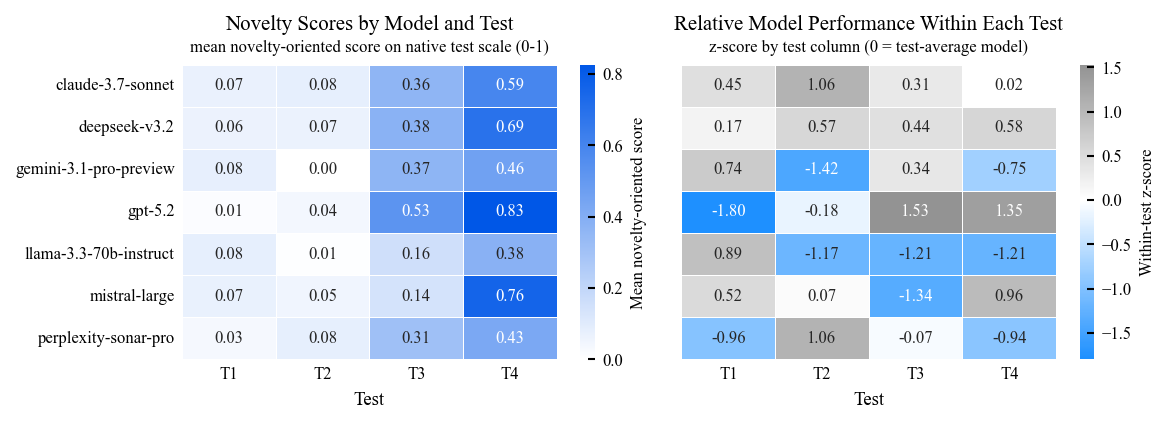

In [115]:
# Visualization: heatmap ensures every test contributes where data exists.
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

hm_left = sns.heatmap(
    cross_test_model_matrix,
    cmap=WHITE_SKY_CMAP,
    annot=True,
    annot_kws={'fontsize': 8},
    fmt='.2f',
    linewidths=0.3,
    cbar_kws={'label': 'Mean novelty-oriented score'},
    ax=axes[0],
)
cbar_left = hm_left.collections[0].colorbar
cbar_left.ax.tick_params(labelsize=8)
cbar_left.set_label('Mean novelty-oriented score', size=8)
axes[0].set_title('Novelty Scores by Model and Test', y=1.12, pad=0)
axes[0].text(0.5, 1.03, 'mean novelty-oriented score on native test scale (0-1)', transform=axes[0].transAxes, ha='center', va='bottom', fontsize=8)
axes[0].set_xlabel('Test')
axes[0].set_ylabel('')
axes[0].tick_params(left=False, bottom=False)

hm_right = sns.heatmap(
    cross_test_model_matrix_z,
    cmap=SKY_WHITE_GRAY_CMAP,
    center=0.0,
    annot=True,
    annot_kws={'fontsize': 8},
    fmt='.2f',
    linewidths=0.3,
    cbar_kws={'label': 'Within-test z-score'},
    ax=axes[1],
)
cbar_right = hm_right.collections[0].colorbar
cbar_right.ax.tick_params(labelsize=8)
cbar_right.set_label('Within-test z-score', size=8)
axes[1].set_title('Relative Model Performance Within Each Test', y=1.12, pad=0)
axes[1].text(0.5, 1.03, 'z-score by test column (0 = test-average model)', transform=axes[1].transAxes, ha='center', va='bottom', fontsize=8)
axes[1].set_xlabel('Test')
axes[1].set_ylabel('')
axes[1].tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('results/overview/cross-test_model-comparison.png', bbox_inches='tight')
print('Cross-test model comparison heatmaps saved to: results/overview/cross-test_model-comparison.png')
plt.show()

### Interpreting the Cross-Model Comparison Heatmaps

Two complementary views of model performance are shown above:

**Left — Raw metric scale**
Each cell shows the mean novelty-oriented score for a given model (row) on a given test (column). The exact metric used per test differs (see the "Metric legend" table above), so absolute values are **not directly comparable across columns**. Use this heatmap to see each model's magnitude within a single test and to spot models with missing data (shown as blank/grey cells).

**Right — Within-test z-score**
Each column is standardized independently (zero mean, unit standard deviation across models). A value of **0** means the model performed at the average for that test; **positive** values indicate above-average performance; **negative** values indicate below-average performance. Missing entries (model not evaluated in that test) are filled with 0, i.e. treated as neutral. Because each column is scaled independently, **z-scores are comparable across columns** and reveal which models consistently outperform or underperform their peers across all four tests.


## 4. Visualization: Overview of Key Findings

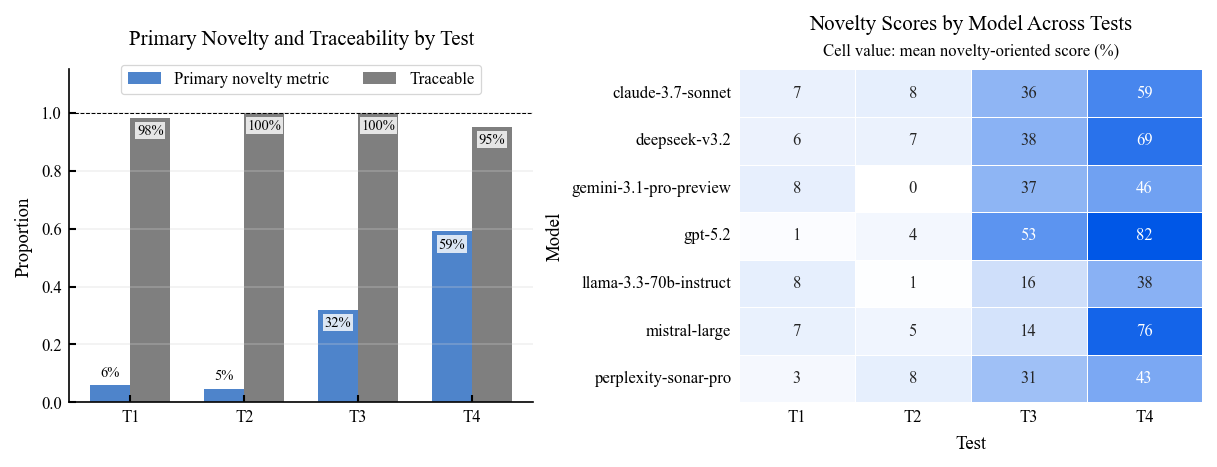

In [105]:
# Create overview visualizations split into two 1x2 figures
test_labels = ['T1', 'T2', 'T3', 'T4']
test_label_map = [
    'T1: Ontological Innovation',
    'T2: Epistemic Agency',
    'T3: Theory Generation',
    'T4: Category Recognition',
]

plot_stats = all_stats
similarity_alert = ANALYSIS_CONFIG.get('similarity_alert_threshold', OVERVIEW_SIMILARITY_ALERT_THRESHOLD)
alt_threshold = ANALYSIS_CONFIG.get('test4_alternative_novelty_threshold', OVERVIEW_TEST4_ALTERNATIVE_NOVELTY_THRESHOLD)

# ---------- Figure A: Primary novelty/traceability + model matrix ----------
fig_a, axes_a = plt.subplots(1,2, figsize=(8, 3),
                             constrained_layout=True,
                             gridspec_kw={'width_ratios': [1.0, 1.0]},
                             )

# Plot A1: Primary novelty vs traceability
ax1 = axes_a[0]
novel_props = [stat.get('prop_novel', np.nan) for stat in plot_stats]
traceable_props = [stat.get('prop_traceable', np.nan) for stat in plot_stats]

x = np.arange(len(test_labels))
width = 0.35
bar_novel = ax1.bar(x - width / 2, novel_props, width, label='Primary novelty metric', color=BLUE_GRAY_RAMP[1], alpha=0.85)
bar_trace = ax1.bar(x + width / 2, traceable_props, width, label='Traceable', color=THRESHOLD_COLOR, alpha=0.80)

ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1.15)
ax1.set_title('Primary Novelty and Traceability by Test')
ax1.set_xticks(x)
ax1.set_xticklabels(test_labels)
ax1.legend(bbox_to_anchor=(0.5, 0.9), loc='lower center', ncol=2)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=1.0, color='black', linewidth=0.5, linestyle='--')

for bars, vals in [(bar_novel, novel_props), (bar_trace, traceable_props)]:
    for rect, val in zip(bars, vals):
        x_center = rect.get_x() + rect.get_width() / 2
        if np.isnan(val):
            label = 'N/A'
            y_text = 0.06
            v_align = 'bottom'
        else:
            label = '0%' if np.isclose(val, 0.0) else f'{val:.0%}'
            if float(val) < 0.2:
                y_text = min(float(val) + 0.02, 1.03)
                v_align = 'bottom'
            else:
                y_text = max(float(val) - 0.02, 0.03)
                v_align = 'top'
        ax1.text(
            x_center,
            y_text,
            label,
            ha='center',
            va=v_align,
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.8),
            zorder=4,
            clip_on=False,
            fontsize=7,
        )

# Plot A2: Model comparison matrix
ax2 = axes_a[1]
if 'cross_test_model_matrix' in globals() and isinstance(cross_test_model_matrix, pd.DataFrame) and not cross_test_model_matrix.empty:
    plot_matrix = cross_test_model_matrix.copy().reindex(columns=test_labels)
    plot_matrix_pct = plot_matrix * 100.0
    sns.heatmap(
        plot_matrix_pct,
        cmap=WHITE_SKY_CMAP,
        annot=True,
        annot_kws={'fontsize': 8},
        fmt='.0f',
        linewidths=0.3,
        cbar=False,
        ax=ax2,
    )
    ax2.set_title('Novelty Scores by Model Across Tests', y=1.12, pad=0)
    ax2.text(0.5, 1.03, 'Cell value: mean novelty-oriented score (%)', transform=ax2.transAxes, ha='center', va='bottom', fontsize=8)
    ax2.set_xlabel('Test')
    ax2.set_ylabel('Model')
    ax2.tick_params(left=False, bottom=False)
else:
    ax2.text(0.5, 0.5, 'Run Cell 14 first', transform=ax2.transAxes, ha='center', va='center', color=TEXT_COLOR)
    ax2.set_title('Novelty Scores by Model Across Tests', y=1.12, pad=0)
    ax2.text(0.5, 1.03, 'Cell value: mean novelty-oriented score (%)', transform=ax2.transAxes, ha='center', va='bottom', fontsize=8)

fig_a.savefig('results/overview/findings_dashboard_A.png', bbox_inches='tight')
plt.show()

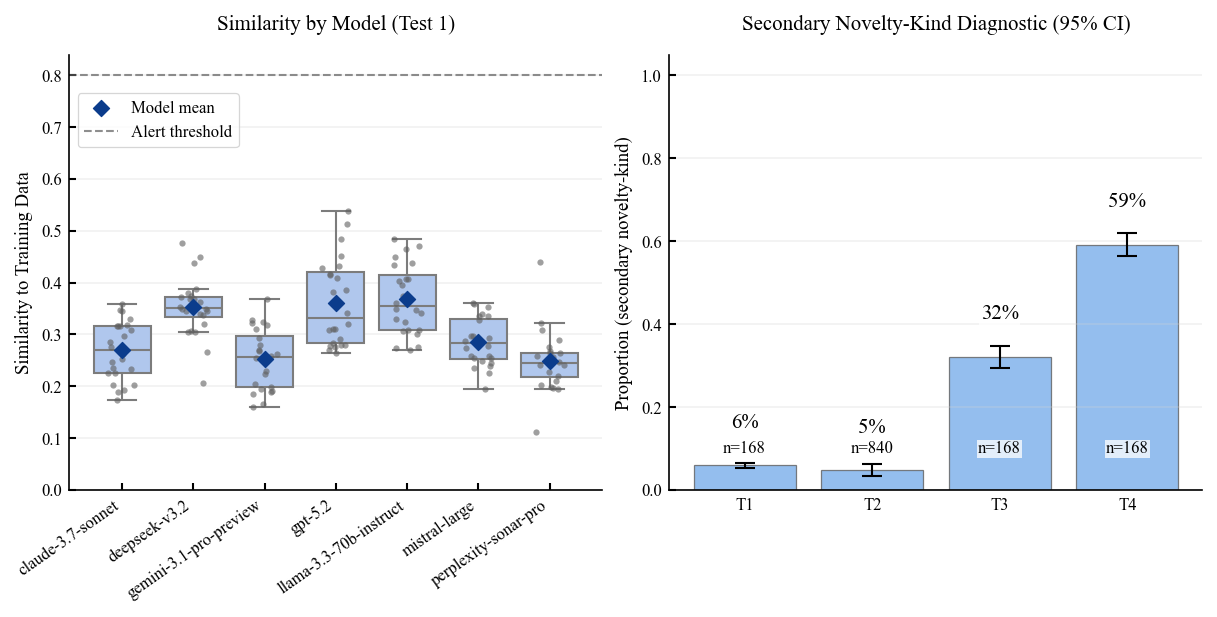


Overview visualizations saved to:
 - results/overview/findings_dashboard_A.png
 - results/overview/findings_dashboard_B.png
Figure note: T1: Ontological Innovation | T2: Epistemic Agency | T3: Theory Generation | T4: Category Recognition | Primary novelty metric is test-specific (Cell 14 legend). Secondary novelty-kind is retained only as a diagnostic. T4 still provisional. Similarity alert: 0.8


In [106]:
# ---------- Figure B: Similarity diagnostics + secondary novelty-kind ----------
fig_b, axes_b = plt.subplots(1,2, figsize=(8, 4), 
                             constrained_layout=True,
                             gridspec_kw={'width_ratios': [1.1, 1.1]},
)

# Plot B1: Similarity by model (Test 1)
ax3 = axes_b[0]
sim_summary_df = pd.DataFrame()
if 'test1_results' in globals() and 'model' in test1_results.columns:
    sim_col = next((c for c in test1_results.columns if c.lower() in ['max_similarity', 'similarity']), None)
    if sim_col is not None:
        sim_df = test1_results[['model', sim_col]].copy()
        sim_df.columns = ['model', 'similarity']
        sim_df['similarity'] = pd.to_numeric(sim_df['similarity'], errors='coerce')
        sim_df = sim_df.dropna(subset=['similarity'])

        order = sorted(sim_df['model'].unique().tolist())
        sns.boxplot(data=sim_df, x='model', y='similarity', order=order, ax=ax3, showfliers=False, color=WHITE_SKY_CMAP(0.35))
        sns.stripplot(data=sim_df, x='model', y='similarity', order=order, ax=ax3, size=3, jitter=0.2, alpha=0.6, color=THRESHOLD_COLOR)

        means = sim_df.groupby('model', observed=True, as_index=False)['similarity'].mean()
        means = means.set_index('model').reindex(order).reset_index()
        ax3.scatter(np.arange(len(order)), means['similarity'], color=BLUE_GRAY_RAMP[0], marker='D', s=30, label='Model mean', zorder=3)

        sim_summary_df = (
            sim_df.groupby('model', observed=True)['similarity']
            .agg(n='count', mean='mean', median='median', max='max')
            .sort_values('mean', ascending=False)
            .round(4)
            .reset_index()
        )

        y_top = max(similarity_alert * 1.05, float(sim_df['similarity'].max()) * 1.15)
        ax3.set_ylim(0, y_top)
        ax3.axhline(y=similarity_alert, color=THRESHOLD_COLOR, linestyle='--', alpha=0.7, label='Alert threshold')
        ax3.tick_params(axis='x', labelrotation=35)
        for tick in ax3.get_xticklabels():
            tick.set_ha('right')
        ax3.legend(loc='upper left', bbox_to_anchor=(0.0, 0.93))

ax3.set_xlabel('')
ax3.set_ylabel('Similarity to Training Data')
ax3.set_title('Similarity by Model (Test 1)')
ax3.grid(axis='y', alpha=0.3)

# Plot B2: Secondary novelty-kind diagnostic
ax4 = axes_b[1]
sample_sizes = [stat['total_samples'] for stat in plot_stats]
novel_kind_rates = [stat.get('prop_novel_kind', stat.get('prop_novel', np.nan)) for stat in plot_stats]
ci_widths = [
    (stat['prop_novel_kind_ci'][1] - stat['prop_novel_kind_ci'][0])
    if 'prop_novel_kind_ci' in stat
    else ((stat['prop_novel_ci'][1] - stat['prop_novel_ci'][0]) if 'prop_novel_ci' in stat else np.nan)
    for stat in plot_stats
]

yerr = [w / 2 if not np.isnan(w) else 0.0 for w in ci_widths]
bar4 = ax4.bar(test_labels, novel_kind_rates, yerr=yerr, capsize=5, color=BLUE_GRAY_RAMP[2], alpha=0.8, edgecolor=THRESHOLD_COLOR)
ax4.set_ylabel('Proportion (secondary novelty-kind)')
ax4.set_ylim(0, 1.05)
ci_pct = int(round((ANALYSIS_CONFIG.get('confidence_level', OVERVIEW_CONFIDENCE_LEVEL)) * 100))
ax4.set_title(f'Secondary Novelty-Kind Diagnostic ({ci_pct}% CI)')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(bottom=False)

for i, (size, rate) in enumerate(zip(sample_sizes, novel_kind_rates)):
    x_center = bar4[i].get_x() + bar4[i].get_width() / 2
    if np.isfinite(rate):
        rate_label = '0%' if np.isclose(rate, 0.0) else f'{rate:.0%}'
        y_rate = min(float(rate) + 0.08, 1.02)
    else:
        rate_label = 'N/A'
        y_rate = 0.05

    ax4.text(
        x_center,
        y_rate,
        rate_label,
        ha='center',
        va='bottom',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.8),
        zorder=4,
        clip_on=False,
        fontsize=10,
    )
    ax4.text(
        x_center,
        0.08,
        f'n={size}',
        ha='center',
        va='bottom',
        color='black',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.75, pad=0.6),
        zorder=4,
        fontsize=8,
    )

fig_b.savefig('results/overview/findings_dashboard_B.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nOverview visualizations saved to:')
print(' - results/overview/findings_dashboard_A.png')
print(' - results/overview/findings_dashboard_B.png')
print('Figure note: ' + ' | '.join(test_label_map) + f' | Primary novelty metric is test-specific (Cell 14 legend). Secondary novelty-kind is retained only as a diagnostic. T4 still provisional. Similarity alert: {similarity_alert:g}')

In [107]:
if not sim_summary_df.empty:
    print("\nTest 1 similarity summary by model:")
    display(sim_summary_df)


Test 1 similarity summary by model:


,model,n,mean,median,max
0,llama-3.3-70b-instruct,24,0.3678,0.3550,0.4837
1,gpt-5.2,24,0.3613,0.3315,0.5383
2,deepseek-v3.2,24,0.3523,0.3507,0.4758
3,mistral-large,24,0.2851,0.2828,0.3609
4,claude-3.7-sonnet,24,0.2692,0.2691,0.3585
5,gemini-3.1-pro-preview,24,0.2522,0.2568,0.3687
6,perplexity-sonar-pro,24,0.2491,0.2458,0.4407


## 5. Statistical Summary Report

In [108]:
# Safely extract overall novelty / traceability across tests
all_novel = [stat['prop_novel'] for stat in all_stats if 'prop_novel' in stat]
all_traceable = [stat['prop_traceable'] for stat in all_stats if 'prop_traceable' in stat]

mean_novel = float(np.mean(all_novel)) if all_novel else np.nan
mean_traceable = float(np.mean(all_traceable)) if all_traceable else np.nan
alpha = ANALYSIS_CONFIG.get('significance_alpha', OVERVIEW_SIGNIFICANCE_ALPHA) if 'ANALYSIS_CONFIG' in globals() else OVERVIEW_SIGNIFICANCE_ALPHA

# p_value may come from ANOVA / chi-square; guard when tests are skipped.
has_sig_test = False
sig_text = "model comparison tests were not run or are unavailable"
if 'p_value' in globals() and p_value is not None:
    try:
        p_float = float(p_value)
        if np.isfinite(p_float):
            has_sig_test = True
            sig_text = f"{'significant' if p_float < alpha else 'no significant'} differences between models"
    except (TypeError, ValueError):
        pass

report = {
    "summary": {
        "total_samples_all_tests": int(sum(stat["total_samples"] for stat in all_stats)),
        "total_models": int(len(set(m for stat in all_stats for m in stat["models"]))),
        "tests_conducted": int(len(all_stats)),
    },
    "key_findings": [
        f"Across all tests, {mean_novel:.1%} of outputs were classified as potentially novel"
        if not np.isnan(mean_novel)
        else "Novelty proportions could not be computed for all tests",
        f"However, {mean_traceable:.1%} of outputs were traceable to training data"
        if not np.isnan(mean_traceable)
        else "Traceability proportions could not be computed for all tests",
        f"Consistency observed across {len(set(m for stat in all_stats for m in stat['models']))} different AI models",
        f"Statistical analysis reveals {sig_text}"
        if has_sig_test
        else f"Statistical analysis: {sig_text}",
    ],
    "test_details": all_stats,
}

# Save report
with open("results/overview_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("\n=== SUMMARY REPORT ===")
print(f"Total samples analyzed: {report['summary']['total_samples_all_tests']:,}")
print(f"Models tested: {report['summary']['total_models']}")
print(f"Tests conducted: {report['summary']['tests_conducted']}")
print("\nKey findings:")
for i, finding in enumerate(report["key_findings"], 1):
    print(f"  {i}. {finding}")

print("\nFull report saved to results/overview_report.json")


=== SUMMARY REPORT ===
Total samples analyzed: 1,344
Models tested: 7
Tests conducted: 4

Key findings:
  1. Across all tests, 25.5% of outputs were classified as potentially novel
  2. However, 98.4% of outputs were traceable to training data
  3. Consistency observed across 7 different AI models
  4. Statistical analysis: model comparison tests were not run or are unavailable

Full report saved to results/overview_report.json


## 6. Prepare Data for Sections 5.2-5.7

Export organized data for detailed analysis in subsequent sections.

In [109]:
# Export cleaned data for each test
test1_results.to_csv('results/test1_cleaned.csv', index=False)
test2_results.to_csv('results/test2_cleaned.csv', index=False)
test3_results.to_csv('results/test3_cleaned.csv', index=False)
test4_results.to_csv('results/test4_cleaned.csv', index=False)

print("Cleaned data exported for detailed analysis in sections 5.2-5.7")
print("\n=== SECTION 5.1 ANALYSIS COMPLETE ===")

Cleaned data exported for detailed analysis in sections 5.2-5.7

=== SECTION 5.1 ANALYSIS COMPLETE ===


## 7. Interactive Threshold & Parameter Explorer

Use this panel to adjust thresholds and immediately inspect how summary indicators and diagnostics change. It is intended for sensitivity analysis, while preserving strict pipeline definitions by default.

In [110]:

# Interactive dashboard for threshold sensitivity analysis
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as exc:
    raise ImportError(
        "ipywidgets is required for the interactive panel. Install with `pip install ipywidgets` and restart kernel."
    ) from exc


def _pick_col(df: pd.DataFrame, candidates: List[str]) -> str | None:
    lower_to_orig = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_to_orig:
            return lower_to_orig[c.lower()]
    return None


def _as_binary(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float)
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce').astype(float)
    mapping = {
        'true': 1.0, 't': 1.0, 'yes': 1.0, 'y': 1.0, '1': 1.0,
        'false': 0.0, 'f': 0.0, 'no': 0.0, 'n': 0.0, '0': 0.0,
    }
    return series.astype(str).str.strip().str.lower().map(mapping).astype(float)


def _extract_novelty_series(df: pd.DataFrame, novelty_thr: float, t4_alt_thr: float) -> tuple[pd.Series | None, str, bool, pd.Series | None]:
    """Return binary novelty, label, whether source is continuous, and optional continuous source.

    Priority mirrors the per-test section notebooks:
      T1 → continuous_novelty_score (hybrid frontier score)
      T3 → continuous_literature_novelty (literature-grounded score)
      T4 → total_score / 15         (normalized 0-15 scale)
      T2 → transcends_framework     (binary transcendence flag)
    """
    # Continuous scores: T1, T3 (literature-grounded), then generic alternatives.
    col = _pick_col(df, ['continuous_novelty_score', 'continuous_literature_novelty', 'literature_novelty_score', 'global_novelty_score', 'novelty_score', 'novelty_ratio'])
    if col is not None:
        cont = pd.to_numeric(df[col], errors='coerce').clip(0, 1)
        return cont.ge(novelty_thr).astype(float), f"{col} >= {novelty_thr:g}", True, cont

    # T4: total_score normalized to [0,1] (raw 0-15 scale)
    col = _pick_col(df, ['total_score'])
    if col is not None:
        cont = (pd.to_numeric(df[col], errors='coerce') / 15.0).clip(0, 1)
        return cont.ge(novelty_thr).astype(float), f"{col} / 15 >= {novelty_thr:g}", True, cont

    # Binary flags: T2 (transcends_framework) prioritized before other binary flags
    col = _pick_col(df, ['transcends_framework', 'is_transcendent', 'is_novel', 'ontologically_novel', 'novel_non_functionalist', 'original'])
    if col is not None:
        b = _as_binary(df[col])
        return b, f"{col} (binary)", False, None

    return None, 'no novelty metric', False, None


def _extract_trace_series(
    df: pd.DataFrame,
    test_title: str,
    t3_similarity_thr: float,
    similarity_alert_thr: float,
    use_strict_t3_flag: bool,
) -> tuple[pd.Series | None, str]:
    # Test 3 strict mode follows upstream pipeline labels.
    if test_title == 'Test 3: Theory Generation' and use_strict_t3_flag:
        col = _pick_col(df, ['is_traceable'])
        if col is not None:
            return _as_binary(df[col]), f"{col} (strict pipeline)"

    if test_title == 'Test 3: Theory Generation':
        sim_col = _pick_col(df, ['max_similarity', 'similarity'])
        der_col = _pick_col(df, ['likely_derivative'])
        if sim_col is not None:
            sim_flag = pd.to_numeric(df[sim_col], errors='coerce').ge(t3_similarity_thr)
            if der_col is not None:
                der_flag = _as_binary(df[der_col]).fillna(0).ge(0.5)
                return (sim_flag | der_flag).astype(float), f"({sim_col} >= {t3_similarity_thr:g}) OR {der_col}"
            return sim_flag.astype(float), f"{sim_col} >= {t3_similarity_thr:g}"

    col = _pick_col(df, ['is_traceable'])
    if col is not None:
        return _as_binary(df[col]), f"{col} (binary)"

    col = _pick_col(df, ['lit_matches'])
    if col is not None:
        return pd.to_numeric(df[col], errors='coerce').fillna(0).gt(0).astype(float), f"{col} > 0"

    col = _pick_col(df, ['training_derived', 'likely_derivative'])
    if col is not None:
        return _as_binary(df[col]), f"{col} (binary)"

    col = _pick_col(df, ['max_similarity', 'similarity'])
    if col is not None:
        return pd.to_numeric(df[col], errors='coerce').ge(similarity_alert_thr).astype(float), f"{col} >= {similarity_alert_thr:g}"

    return None, 'no traceability metric'


def _build_dashboard_data(
    novelty_thr: float,
    t3_similarity_thr: float,
    similarity_alert_thr: float,
    t4_alt_thr: float,
    use_strict_t3_flag: bool,
):
    tests = [
        ('T1', 'Test 1: Ontological Innovation', test1_results),
        ('T2', 'Test 2: Epistemic Agency', test2_results),
        ('T3', 'Test 3: Theory Generation', test3_results),
        ('T4', 'Test 4: Category Recognition', test4_results),
    ]

    summary_rows = []
    legend_rows = []
    model_blocks = []
    per_test_payload = {}

    for code, title, df in tests:
        model_col = _pick_col(df, ['model'])
        novelty_b, novelty_label, novelty_is_cont, novelty_cont = _extract_novelty_series(df, novelty_thr, t4_alt_thr)
        trace_b, trace_label = _extract_trace_series(df, title, t3_similarity_thr, similarity_alert_thr, use_strict_t3_flag)

        legend_rows.append({
            'test': code,
            'novelty_metric': novelty_label,
            'traceability_metric': trace_label,
        })

        work = pd.DataFrame(index=df.index)
        if model_col is not None:
            work['model'] = df[model_col].astype(str)
        else:
            work['model'] = 'unknown'

        if novelty_b is not None:
            work['novelty_binary'] = pd.to_numeric(novelty_b, errors='coerce')
        if trace_b is not None:
            work['traceability_binary'] = pd.to_numeric(trace_b, errors='coerce')

        sim_col = _pick_col(df, ['max_similarity', 'similarity'])
        if sim_col is not None:
            work['similarity'] = pd.to_numeric(df[sim_col], errors='coerce')

        # Keep continuous novelty for selected-test diagnostics.
        if novelty_is_cont and novelty_cont is not None:
            work['novelty_continuous'] = pd.to_numeric(novelty_cont, errors='coerce')

        work = work.dropna(subset=['model'])

        prop_novel = float(work['novelty_binary'].mean()) if 'novelty_binary' in work else np.nan
        prop_trace = float(work['traceability_binary'].mean()) if 'traceability_binary' in work else np.nan

        summary_rows.append({
            'test_code': code,
            'test_name': title,
            'n': int(len(work)),
            'prop_novel': prop_novel,
            'prop_traceable': prop_trace,
            'ratio_novel_to_traceable': (prop_novel / prop_trace) if np.isfinite(prop_novel) and np.isfinite(prop_trace) and prop_trace > 0 else np.nan,
        })

        if 'novelty_binary' in work:
            model_block = (
                work.groupby('model', as_index=False)['novelty_binary']
                .mean()
                .rename(columns={'novelty_binary': 'mean'})
            )
            model_block['test'] = code
            model_blocks.append(model_block)

        per_test_payload[title] = work

    summary_df_local = pd.DataFrame(summary_rows)
    legend_df_local = pd.DataFrame(legend_rows)

    if model_blocks:
        model_df = pd.concat(model_blocks, ignore_index=True)
        matrix = model_df.pivot_table(index='model', columns='test', values='mean', aggfunc='mean')
        matrix = matrix.reindex(columns=['T1', 'T2', 'T3', 'T4'])
    else:
        matrix = pd.DataFrame()

    return summary_df_local, legend_df_local, matrix, per_test_payload


def _render_dashboard(
    novelty_threshold: float,
    test3_traceability_threshold: float,
    similarity_alert_threshold: float,
    test4_alternative_threshold: float,
    selected_test: str,
    use_strict_test3_traceability: bool,
):
    summary_local, legend_local, matrix_local, payload = _build_dashboard_data(
        novelty_thr=novelty_threshold,
        t3_similarity_thr=test3_traceability_threshold,
        similarity_alert_thr=similarity_alert_threshold,
        t4_alt_thr=test4_alternative_threshold,
        use_strict_t3_flag=use_strict_test3_traceability,
    )

    fig, axes = plt.subplots(2, 2, figsize=(8, 6))

    # Plot 1: Novelty vs traceability by test.
    ax1 = axes[0, 0]
    x = np.arange(len(summary_local))
    width = 0.35
    ax1.bar(x - width / 2, summary_local['prop_novel'].values, width, label='Novel', color=BLUE_GRAY_RAMP[1], alpha=0.85)
    ax1.bar(x + width / 2, summary_local['prop_traceable'].values, width, label='Traceable', color=THRESHOLD_COLOR, alpha=0.80)
    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_local['test_code'].tolist())
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Proportion')
    ax1.set_title('Novelty vs Traceability (Adjusted Parameters)')
    ax1.grid(axis='y', alpha=0.3)
    ax1.legend(loc='upper right')

    # Plot 2: Model-test heatmap using adjusted novelty definition.
    ax2 = axes[0, 1]
    if not matrix_local.empty:
        sns.heatmap(
            matrix_local,
            cmap=WHITE_SKY_CMAP,
            annot=True,
            annot_kws={'fontsize': 8},
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Mean binary novelty'},
            ax=ax2,
        )
    else:
        ax2.text(0.5, 0.5, 'No model matrix available', transform=ax2.transAxes, ha='center', va='center')
    ax2.set_title('Model x Test Heatmap')
    ax2.tick_params(left=False, bottom=False)

    # Plot 3: Selected-test novelty distribution.
    ax3 = axes[1, 0]
    d = payload.get(selected_test, pd.DataFrame()).copy()
    if 'novelty_continuous' in d.columns and d['novelty_continuous'].notna().any():
        vals = d['novelty_continuous'].dropna().values
        ax3.hist(vals, bins=15, color=SIMILARITY_HIST_COLOR, alpha=0.75)
        ax3.axvline(novelty_threshold, linestyle='--', color=THRESHOLD_COLOR, label=f'Novelty thr {novelty_threshold:g}')
        ax3.set_xlim(0, 1)
        ax3.set_xlabel('Continuous novelty score')
        ax3.legend()
    elif 'novelty_binary' in d.columns and d['novelty_binary'].notna().any():
        counts = d['novelty_binary'].value_counts(dropna=True).reindex([0.0, 1.0], fill_value=0)
        ax3.bar(['0', '1'], counts.values, color=[BLUE_GRAY_RAMP[4], BLUE_GRAY_RAMP[1]], alpha=0.85)
        ax3.set_xlabel('Binary novelty')
    else:
        ax3.text(0.5, 0.5, 'No novelty data', transform=ax3.transAxes, ha='center', va='center')
    ax3.set_title(f'Novelty Distribution: {selected_test}')
    ax3.grid(axis='y', alpha=0.3)

    # Plot 4: Selected-test similarity diagnostics.
    ax4 = axes[1, 1]
    if 'similarity' in d.columns and d['similarity'].notna().any():
        sns.boxplot(data=d, x='model', y='similarity', ax=ax4, showfliers=False, color=WHITE_SKY_CMAP(0.35))
        ax4.axhline(similarity_alert_threshold, linestyle='--', color=THRESHOLD_COLOR, alpha=0.75, label=f'Alert thr {similarity_alert_threshold:g}')
        if selected_test == 'Test 3: Theory Generation' and not use_strict_test3_traceability:
            ax4.axhline(test3_traceability_threshold, linestyle=':', color=BLUE_GRAY_RAMP[0], alpha=0.9, label=f'T3 trace thr {test3_traceability_threshold:g}')
        ax4.tick_params(axis='x', labelrotation=35)
        for tick in ax4.get_xticklabels():
            tick.set_ha('right')
        ax4.legend(loc='upper left')
    else:
        ax4.text(0.5, 0.5, 'No similarity data', transform=ax4.transAxes, ha='center', va='center')
    ax4.set_title(f'Similarity Diagnostic: {selected_test}')
    ax4.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print('Metric mapping with current settings:')
    display(legend_local)

    print('Adjusted summary table:')
    display(summary_local)


# Controls
selected_test_options = [
    'Test 1: Ontological Innovation',
    'Test 2: Epistemic Agency',
    'Test 3: Theory Generation',
    'Test 4: Category Recognition',
]

# Default values from thresholds.py
_DEFAULT_NOVELTY_THR  = float(OVERVIEW_NOVELTY_BINARY_THRESHOLD)
_DEFAULT_T3_TRACE_THR = float(OVERVIEW_T3_TRACEABILITY_SIMILARITY_THRESHOLD)
_DEFAULT_SIM_ALERT    = float(OVERVIEW_SIMILARITY_ALERT_THRESHOLD)
_DEFAULT_T4_ALT_THR   = float(OVERVIEW_TEST4_ALTERNATIVE_NOVELTY_THRESHOLD)

novelty_slider = widgets.FloatSlider(
    value=_DEFAULT_NOVELTY_THR,
    min=0.0,
    max=1.0,
    step=0.01,
    description='Novelty thr',
    continuous_update=False,
    readout_format='.2f',
)

t3_trace_slider = widgets.FloatSlider(
    value=_DEFAULT_T3_TRACE_THR,
    min=0.0,
    max=1.0,
    step=0.01,
    description='T3 trace thr',
    continuous_update=False,
    readout_format='.2f',
)

sim_alert_slider = widgets.FloatSlider(
    value=_DEFAULT_SIM_ALERT,
    min=0.0,
    max=1.0,
    step=0.01,
    description='Similarity alert',
    continuous_update=False,
    readout_format='.2f',
)

t4_alt_slider = widgets.FloatSlider(
    value=_DEFAULT_T4_ALT_THR,
    min=1.0,
    max=5.0,
    step=0.1,
    description='T4 alt thr',
    continuous_update=False,
    readout_format='.1f',
)

selected_test_dd = widgets.Dropdown(
    options=selected_test_options,
    value='Test 3: Theory Generation',
    description='Inspect test',
)

strict_t3_toggle = widgets.Checkbox(
    value=True,
    description='Use strict T3 traceability flag',
    indent=False,
)

reset_button = widgets.Button(
    description='Reset to defaults',
    button_style='warning',
    tooltip=(
        f'Reset all sliders to thresholds.py defaults: '
        f'Novelty={_DEFAULT_NOVELTY_THR:g}, '
        f'T3 trace={_DEFAULT_T3_TRACE_THR:g}, '
        f'Sim alert={_DEFAULT_SIM_ALERT:g}, '
        f'T4 alt={_DEFAULT_T4_ALT_THR:g}'
    ),
    icon='undo',
)

def _on_reset(_):
    novelty_slider.value   = _DEFAULT_NOVELTY_THR
    t3_trace_slider.value  = _DEFAULT_T3_TRACE_THR
    sim_alert_slider.value = _DEFAULT_SIM_ALERT
    t4_alt_slider.value    = _DEFAULT_T4_ALT_THR

reset_button.on_click(_on_reset)

controls_left = widgets.VBox([novelty_slider, t3_trace_slider, sim_alert_slider, t4_alt_slider])
controls_right = widgets.VBox([selected_test_dd, strict_t3_toggle, reset_button])
controls = widgets.HBox([controls_left, controls_right])

output = widgets.interactive_output(
    _render_dashboard,
    {
        'novelty_threshold': novelty_slider,
        'test3_traceability_threshold': t3_trace_slider,
        'similarity_alert_threshold': sim_alert_slider,
        'test4_alternative_threshold': t4_alt_slider,
        'selected_test': selected_test_dd,
        'use_strict_test3_traceability': strict_t3_toggle,
    },
)

display(controls, output)


Output()